In [1]:
import torch
from torch import nn

torch.__version__

'2.7.1+cu118'

In [2]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
!nvidia-smi

Sat Jun 14 19:52:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.83                 Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   46C    P8              6W /   50W |     329MiB /   6144MiB |     12%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
#getting the data
from pathlib import Path
import requests
import zipfile

data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"

if image_path.is_dir():
    print("f{image_path} directory already exists ... skipping download")
else :
    print(f"{image_path} does note exist, creating one... ")
    image_path.mkdir(parents=True,exist_ok=True)

#download the data
with open(data_path/"pizza_steak_sushi.zip","wb") as f:
    request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading the file...")
    f.write(request.content)
#unzip the file
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
    print("unzipping data...")
    zip_ref.extractall(image_path)

f{image_path} directory already exists ... skipping download
unzipping data...


In [5]:
import os
def walk_through_dir(dir_path):
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"there are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [6]:
walk_through_dir(image_path)

there are 2 directories and 0 images in data\pizza_steak_sushi
there are 3 directories and 0 images in data\pizza_steak_sushi\test
there are 0 directories and 25 images in data\pizza_steak_sushi\test\pizza
there are 0 directories and 19 images in data\pizza_steak_sushi\test\steak
there are 0 directories and 31 images in data\pizza_steak_sushi\test\sushi
there are 3 directories and 0 images in data\pizza_steak_sushi\train
there are 0 directories and 78 images in data\pizza_steak_sushi\train\pizza
there are 0 directories and 75 images in data\pizza_steak_sushi\train\steak
there are 0 directories and 72 images in data\pizza_steak_sushi\train\sushi


In [8]:
train_dir=image_path/"train"
test_dir=image_path/"test"

test_dir,train_dir

(WindowsPath('data/pizza_steak_sushi/test'),
 WindowsPath('data/pizza_steak_sushi/train'))

In [15]:
import random
from PIL import Image

random.seed(42)
image_path_list=list(image_path.glob("*/*/*.jpg"))

image_path_list

[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2124579.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2218680.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2236338.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2508636.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2871261.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/3092704.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/309892.jp

In [40]:
# random.seed(42)
random_image_path=random.choice(image_path_list)
random_image_path

WindowsPath('data/pizza_steak_sushi/test/sushi/1987407.jpg')

In [41]:
image_class=random_image_path.parent.stem
image_class

'sushi'

random image path: data\pizza_steak_sushi\test\sushi\1987407.jpg
image class : sushi
image height : 384, image width : 512


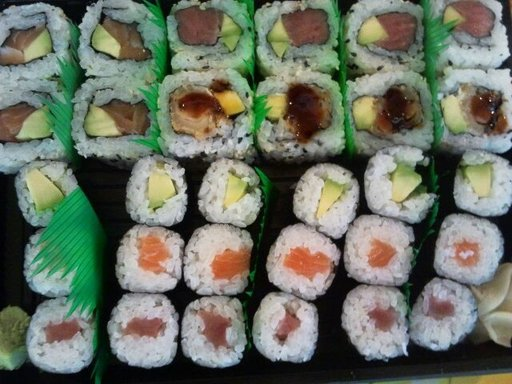

In [42]:
img=Image.open(random_image_path)

print(f"random image path: {random_image_path}")
print(f"image class : {image_class}")
print(f"image height : {img.height}, image width : {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

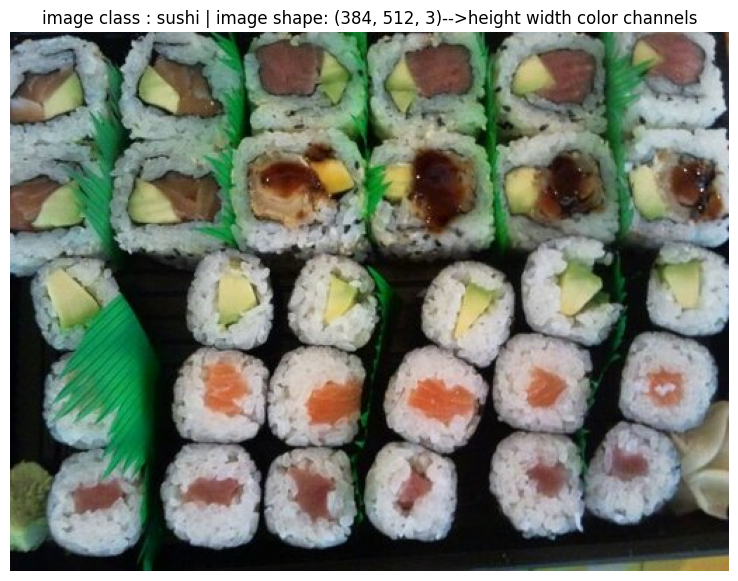

In [43]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array=np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"image class : {image_class} | image shape: {img_as_array.shape}-->height width color channels")
plt.axis(False)

In [44]:
img_as_array

array([[[  9,  22,  30],
        [  2,  15,  23],
        [  9,  19,  28],
        ...,
        [ 81,  58,  42],
        [109,  78,  58],
        [122,  90,  67]],

       [[ 13,  23,  32],
        [  4,  15,  21],
        [ 12,  21,  28],
        ...,
        [ 80,  57,  41],
        [113,  85,  64],
        [134, 102,  79]],

       [[  7,  16,  23],
        [ 13,  22,  27],
        [ 13,  20,  26],
        ...,
        [ 73,  50,  36],
        [109,  80,  62],
        [134, 103,  82]],

       ...,

       [[ 10,   7,  14],
        [  8,   7,  13],
        [  6,   5,  11],
        ...,
        [173, 132,  68],
        [173, 132,  68],
        [173, 132,  68]],

       [[ 12,   7,  14],
        [  9,   6,  13],
        [  7,   4,  11],
        ...,
        [173, 132,  66],
        [174, 130,  65],
        [173, 129,  64]],

       [[ 12,   7,  14],
        [ 11,   6,  13],
        [  9,   4,  11],
        ...,
        [171, 131,  62],
        [172, 128,  63],
        [170, 126,  61]]

In [45]:
#now every img as an array(tensor)

import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [48]:
data_transform=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [52]:
data_transform(img)

tensor([[[0.2157, 0.4431, 0.6706,  ..., 0.1490, 0.1412, 0.0745],
         [0.2078, 0.5608, 0.5843,  ..., 0.4941, 0.4745, 0.2431],
         [0.1647, 0.4941, 0.4588,  ..., 0.5216, 0.5529, 0.4392],
         ...,
         [0.1922, 0.1725, 0.1529,  ..., 0.0745, 0.2353, 0.2039],
         [0.5333, 0.5020, 0.4588,  ..., 0.0196, 0.0196, 0.0235],
         [0.6627, 0.6549, 0.6588,  ..., 0.0196, 0.0157, 0.0196]],

        [[0.1765, 0.4667, 0.6902,  ..., 0.1804, 0.1569, 0.0902],
         [0.1765, 0.5765, 0.5843,  ..., 0.5529, 0.5176, 0.2745],
         [0.1608, 0.5137, 0.4275,  ..., 0.5922, 0.6196, 0.4902],
         ...,
         [0.2157, 0.2000, 0.1765,  ..., 0.1098, 0.3176, 0.2824],
         [0.4784, 0.4627, 0.4314,  ..., 0.0235, 0.0353, 0.0314],
         [0.5294, 0.5412, 0.5412,  ..., 0.0235, 0.0235, 0.0235]],

        [[0.1608, 0.4863, 0.7059,  ..., 0.2078, 0.1725, 0.1098],
         [0.1725, 0.6039, 0.5961,  ..., 0.5961, 0.5451, 0.3059],
         [0.1647, 0.5412, 0.4353,  ..., 0.6314, 0.6667, 0.